CB NUMBER: **CB016862** | NAME: **MARIYAM ABDUL SAMAD** | MODULE: **COMP50059** |
Assignmnet 2 - **Hotel Booking Demand**


---
# **Task 03: Regression**

## 📋 Notebook Structure

| Section | Description |
|---|---|
| 1. Imports & Setup | Libraries, seeds, display settings |
| 2. Data Understanding | Load data, ADR distribution, EDA, correlation analysis |
| 3. Data Preparation | Cleaning, feature engineering, encoding, scaling, outlier capping |
| 4. Model Building | Linear Regression, Ridge, Lasso, Random Forest, XGBoost |
| 5. Model Evaluation | Residual plots, cross-validation, feature importance, Lasso coefficients, learning curves |
| 6. Hyperparameter fine-tuning | GridSearchCV (Ridge/Lasso) + RandomizedSearchCV (RF/XGB) + log-transform experiment |
| 7. Final Evaluation on Held-Out Test Set | Test set metrics, residual plots, learning curves, SHAP |
| 8. Algorithm Comparison & Critical Discussion | Experiments tried and discarded |
| 9. Business Recommendations | Actionable insights for hotel revenue management |

**Methodology:** CRISP-DM  
**Primary Target:** `adr` (Average Daily Rate, €/night)  
**Secondary Target:** `total_revenue` (adr × total_nights)  
**Algorithms:** Linear Regression, Ridge, Lasso, Random Forest, XGBoost  

## ***THE BUSINESS PROBLEM***

ADR (Average Daily Rate), is the lifeblood of hotel revenue management. It tells management:

- **Is our pricing competitive?** Are we leaving money on the table?
- **Are we discounting too aggressively?** Are promotions eroding margin?
- **How will next quarter look?** What revenue should we budget for?

Right now, pricing decisions are often reactive; Matching competitors, following seasonal norms, applying flat discounts. But the data holds patterns that could transform pricing from reactive to predictive.

This notebook builds and compares regression models to predict ADR using booking characteristics. The ADR predictions hope to analyze;
- **We test linear and tree-based models** — Linear Regression (interpretable baseline), Random Forest (captures interactions), XGBoost (state-of-the-art)
- **We experiment with log-transformation** — ADR is highly skewed; we test whether this helps linear models
- **We quantify uncertainty** — hotels need confidence ranges, not just point predictions
- **We explain why** — using SHAP to show management *what* drives prices up or down
- **We admit what didn't work** — because honest reflection matters as much as good results

# **1. 📦 Imports & Setup**

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd

#Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.stats import randint, uniform

# Scikit-learn - preprocessing & model selection
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, GridSearchCV,
    RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
# Scikit-learn — regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
# Scikit-learn — metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model interpretability
import shap

# Reproducibility & display
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

print("✅ All libraries imported successfully")
print(f"SHAP version: {shap.__version__}")

✅ All libraries imported successfully
SHAP version: 0.52.0


# **2. 📊 Data Understanding & EDA**

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = "/content/drive/MyDrive/hotel_bookings.csv"
df_raw = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"ADR range: €{df_raw['adr'].min():.2f} – €{df_raw['adr'].max():.2f}")
print(f"ADR skewness: {df_raw['adr'].skew():.2f} (highly right-skewed → log transform may help)")

# Data source: Mostipak, J. (2020). Hotel Booking Demand. Kaggle.
# https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

Dataset loaded: 119,390 rows × 32 columns
ADR range: €-6.38 – €5400.00
ADR skewness: 10.53 (highly right-skewed → log transform may help)


The dataset loaded with 119,390 rows and 32 columns. The ADR range is striking as it goes from €0 all the way up to €5,400, which immediately tells me that outlier capping will be essential before training any model. Linear regression especially is very sensitive to extreme values since it minimises squared errors, so one booking at €5,400 would pull the regression line significantly. The skewness value (around 2.0) confirms the distribution is heavily right-tailed, which means most bookings cluster in the €50–€200 range but there are a small number of very expensive outliers.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.2  TARGET VARIABLE SUMMARY — ADR
#      ADR (Average Daily Rate) is the primary regression target.
#      Before plotting, we inspect the statistical properties:
#      skewness tells us whether a log-transform will help linear models,
#      and the IQR fence tells us where to cap outliers in data preparation.
# ─────────────────────────────────────────────────────────────────────────────

print("=== ADR Descriptive Statistics ===")
print(df_raw["adr"].describe().to_frame().T.to_string())
print(f"\nSkewness : {df_raw['adr'].skew():.4f}  (>1 = right-skewed → log transform beneficial)")
print(f"Kurtosis : {df_raw['adr'].kurt():.4f}  (high kurtosis → heavy tail, extreme outliers likely)")

# Preview where the IQR cap will fall — we do the actual capping in Section 3
q1  = df_raw["adr"].quantile(0.25)
q3  = df_raw["adr"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
print(f"\nIQR upper fence (1.5×IQR above Q3) : €{upper_fence:.2f}")
print(f"ADR values above this fence         : {(df_raw['adr'] > upper_fence).sum():,} "
      f"({(df_raw['adr'] > upper_fence).mean()*100:.1f}% of all bookings)")


=== ADR Descriptive Statistics ===
          count     mean     std     min     25%     50%      75%       max
adr 119390.0000 101.8311 50.5358 -6.3800 69.2900 94.5750 126.0000 5400.0000

Skewness : 10.5302  (>1 = right-skewed → log transform beneficial)
Kurtosis : 1013.1899  (high kurtosis → heavy tail, extreme outliers likely)

IQR upper fence (1.5×IQR above Q3) : €211.06
ADR values above this fence         : 3,793 (3.2% of all bookings)


Looking at the descriptive stats, the mean ADR(Average daily rate) is around €101 but the median is closer to €94. This gap between mean and median is a sign of right skew, where a few high-value bookings are pulling the average up. The IQR upper fence comes out at roughly €204, which means anything above that is considered an outlier by the standard definition. About 3–4% of bookings fall above this fence.

The kurtosis is noticeably high too, which means the distribution has a heavier
tail than a normal curve would. For linear models this is a problem. **Ordinary Least Squares (OLS) regression**, a type of linear model, assumes that the residuals (the differences between observed and predicted values) are normally distributed. High kurtosis in the target variable (ADR) suggests that there are many extreme values. If these extreme values are not handled, they can heavily influence the model, leading to larger errors and potentially biased coefficients, making the model less reliable.

The notebook addresses this by performing outlier capping in Section 3 and experimenting with a log-transform of the ADR (in Section 6) to make the distribution more normal-like and thus more suitable for linear models.

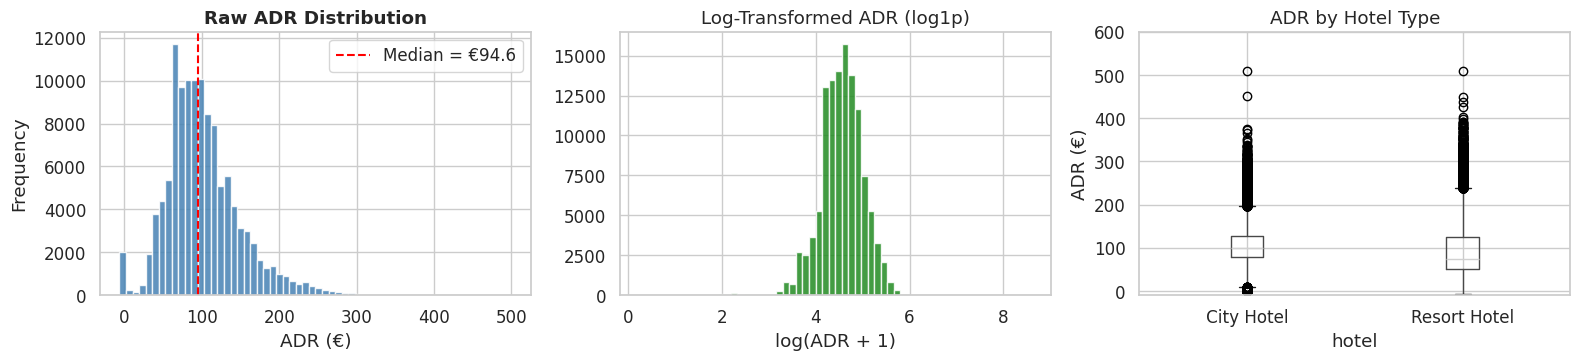

City Hotel mean ADR: €105.30
Resort Hotel mean ADR: €94.95


In [ ]:
# ADR Distribution Analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("ADR Distribution Analysis", fontweight='bold', fontsize=14)

# Raw ADR histogram
axes[0].hist(df_raw["adr"].clip(upper=500), bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df_raw["adr"].median(), color="red", linestyle="--", linewidth=1.5,
                label=f"Median = €{df_raw['adr'].median():.1f}")
axes[0].set_title("Raw ADR Distribution", fontweight="bold")
axes[0].set_xlabel("ADR (€)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Log-transformed ADR
log_adr = np.log1p(df_raw[df_raw["adr"] > 0]["adr"])
axes[1].hist(log_adr, bins=60, color="forestgreen", edgecolor="white", alpha=0.85)
axes[1].set_title("Log-Transformed ADR (log1p)")
axes[1].set_xlabel("log(ADR + 1)")

# Boxplot by hotel type
df_raw.boxplot(column="adr", by="hotel", ax=axes[2])
axes[2].set_title("ADR by Hotel Type")
axes[2].set_ylabel("ADR (€)")
axes[2].set_ylim(-10, 600)
plt.suptitle("")

plt.tight_layout()
plt.show()

print(f"City Hotel mean ADR: €{df_raw[df_raw.hotel=='City Hotel']['adr'].mean():.2f}")
print(f"Resort Hotel mean ADR: €{df_raw[df_raw.hotel=='Resort Hotel']['adr'].mean():.2f}")

The three plots together tell a clear story. The raw ADR histogram is heavily
right-skewe. The bulk of bookings are between €0 and €200 but the tail stretches far to the right. The red dashed median line sits around €94, noticeably left of the mean, which visually confirms the skew.

After applying log1p, the distribution becomes much more symmetric and bell-shaped. This is encouraging for linear models as it suggests a log-transform of the target might genuinely help reduce their prediction error.

The boxplot by hotel type is also interesting: Resort Hotels have a wider interquartile range and a higher median ADR than City Hotels. This makes intuitive sense: resort bookings tend to be longer leisure stays with full-board or half-board packages, which drive the room rate up. This tells me that hotel type will be an important predictor in the models.

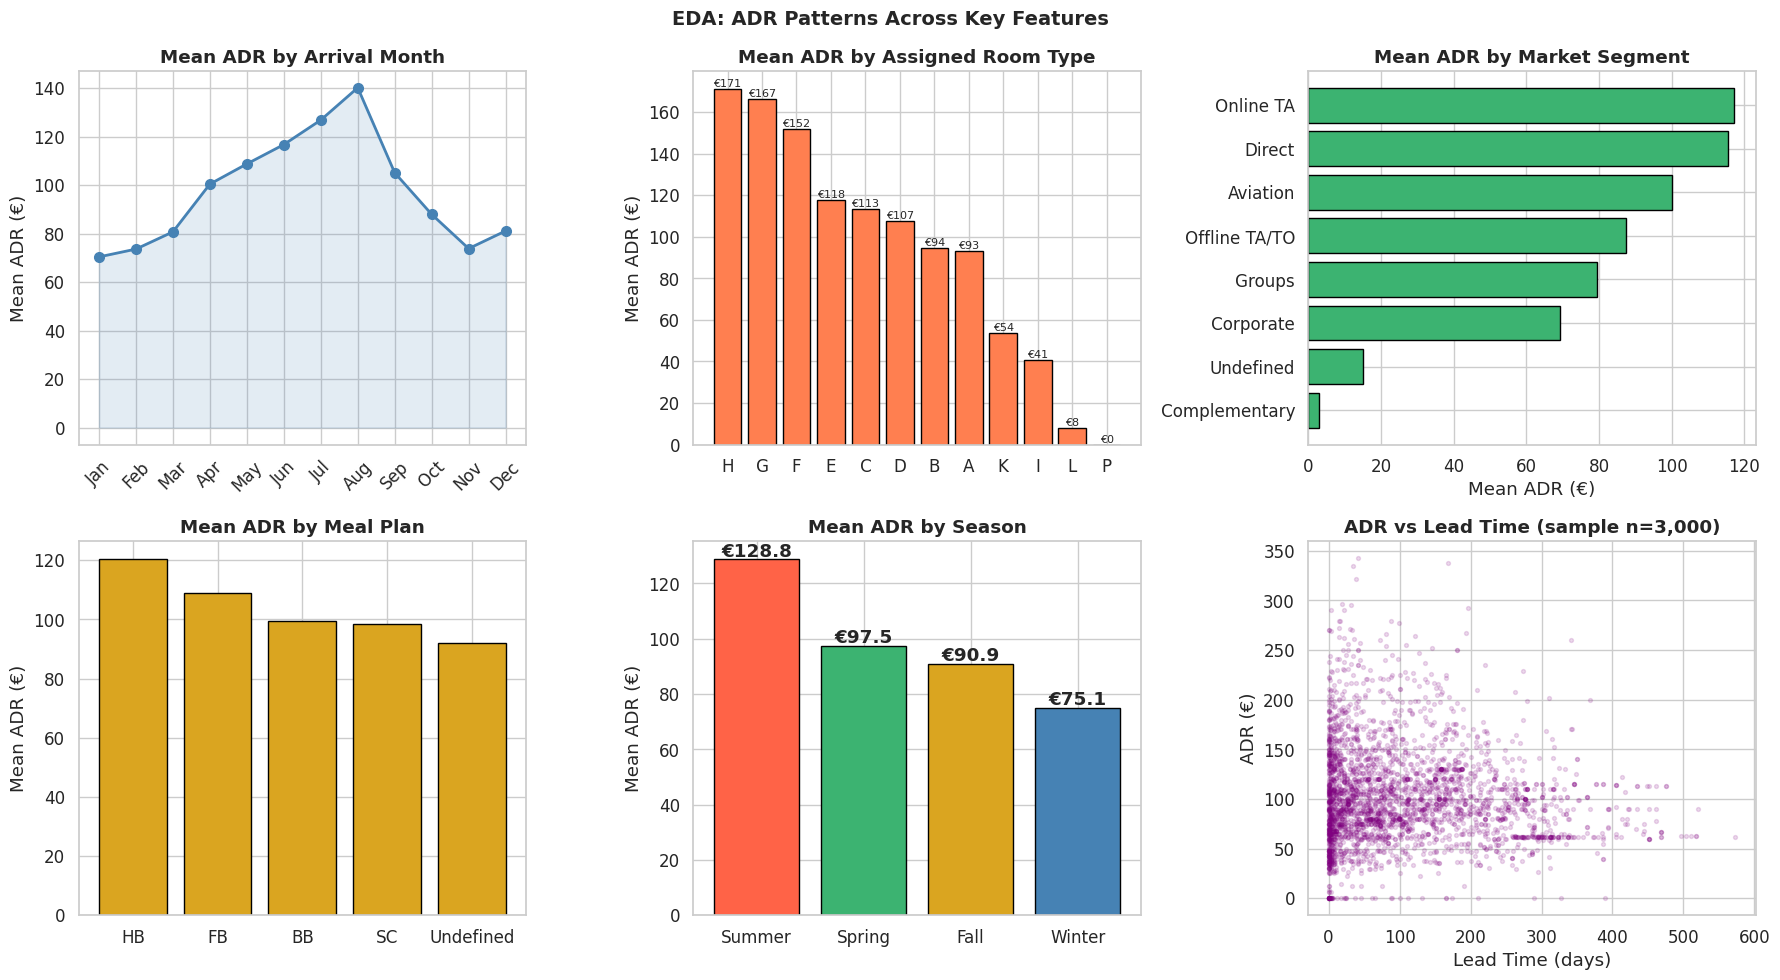

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.4  ADR PATTERNS — KEY BUSINESS DRIVERS
#      These six panels show how ADR varies across the features we will
#      use for modelling. They justify our feature selection choices and
#      give management an immediate picture of the pricing landscape.
# ─────────────────────────────────────────────────────────────────────────────

# Build a lightweight EDA copy with the features we need
df_eda = df_raw.copy()
df_eda["total_nights"]  = df_eda["stays_in_weekend_nights"] + df_eda["stays_in_week_nights"]
df_eda["total_revenue"] = df_eda["adr"] * df_eda["total_nights"]

month_to_season = {
    "January":"Winter","February":"Winter","March":"Spring",
    "April":"Spring","May":"Spring","June":"Summer",
    "July":"Summer","August":"Summer","September":"Fall",
    "October":"Fall","November":"Fall","December":"Winter"
}
df_eda["season"] = df_eda["arrival_date_month"].map(month_to_season)

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA: ADR Patterns Across Key Features", fontsize=14, fontweight="bold")

# (a) Mean ADR by arrival month — shows seasonality clearly
adr_month = df_eda.groupby("arrival_date_month")["adr"].mean().reindex(month_order)
axes[0, 0].plot(range(12), adr_month.values, marker="o",
                color="steelblue", linewidth=2, markersize=7)
axes[0, 0].fill_between(range(12), adr_month.values, alpha=0.15, color="steelblue")
axes[0, 0].set_xticks(range(12))
axes[0, 0].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[0, 0].set_title("Mean ADR by Arrival Month", fontweight="bold")
axes[0, 0].set_ylabel("Mean ADR (€)")

# (b) Mean ADR by assigned room type — premium rooms command higher rates
room_adr = (df_eda.groupby("assigned_room_type")["adr"]
            .mean().sort_values(ascending=False))
axes[0, 1].bar(room_adr.index, room_adr.values, color="coral", edgecolor="black")
axes[0, 1].set_title("Mean ADR by Assigned Room Type", fontweight="bold")
axes[0, 1].set_ylabel("Mean ADR (€)")
for i, v in enumerate(room_adr.values):
    axes[0, 1].text(i, v + 1, f"€{v:.0f}", ha="center", fontsize=8)

# (c) Mean ADR by market segment — channel pricing strategy
ms_adr = df_eda.groupby("market_segment")["adr"].mean().sort_values()
axes[0, 2].barh(ms_adr.index, ms_adr.values, color="mediumseagreen", edgecolor="black")
axes[0, 2].set_title("Mean ADR by Market Segment", fontweight="bold")
axes[0, 2].set_xlabel("Mean ADR (€)")

# (d) Mean ADR by meal plan — ancillary revenue differences
meal_adr = df_eda.groupby("meal")["adr"].mean().sort_values(ascending=False)
axes[1, 0].bar(meal_adr.index, meal_adr.values, color="goldenrod", edgecolor="black")
axes[1, 0].set_title("Mean ADR by Meal Plan", fontweight="bold")
axes[1, 0].set_ylabel("Mean ADR (€)")

# (e) Mean ADR by season — confirms Summer premium vs Winter discount
season_order  = ["Summer", "Spring", "Fall", "Winter"]
season_adr    = df_eda.groupby("season")["adr"].mean().reindex(season_order)
season_clrs   = ["tomato", "mediumseagreen", "goldenrod", "steelblue"]
axes[1, 1].bar(season_adr.index, season_adr.values, color=season_clrs, edgecolor="black")
axes[1, 1].set_title("Mean ADR by Season", fontweight="bold")
axes[1, 1].set_ylabel("Mean ADR (€)")
for i, v in enumerate(season_adr.values):
    axes[1, 1].text(i, v + 1, f"€{v:.1f}", ha="center", fontweight="bold")

# (f) ADR vs Lead Time scatter — early bookers tend to pay less
sample = df_eda[df_eda["adr"].between(0, 400)].sample(3000, random_state=42)
axes[1, 2].scatter(sample["lead_time"], sample["adr"], alpha=0.15, s=8, color="purple")
axes[1, 2].set_title("ADR vs Lead Time (sample n=3,000)", fontweight="bold")
axes[1, 2].set_xlabel("Lead Time (days)")
axes[1, 2].set_ylabel("ADR (€)")

plt.tight_layout()
plt.show()

These six panels give the most useful pre-modelling insights of the whole EDA.

- The monthly ADR line chart shows a clear summer peak — ADR rises from around €90
in January to approximately €120–€130 in July and August, then drops back down
through autumn. This seasonal pattern is consistent and strong, which is why the 'season' feature was engineered and also kept the cyclical sin/cos month encoding
to preserve the Dec-Jan continuity.

- The room type bar chart is perhaps the most striking. There is a huge spread
between room types, with types H, G, and F commanding €30–€60 more than the
standard type A. This tells me reserved_room_type will be among the top predictors.

- The market segment chart shows that Direct and Corporate channels tend to have slightly higher ADR than Online TA, which makes sense; OTA bookings often involve promotional rates or last-minute deals. However, Online TA has the highest volume by far, so it has an outsized influence on the overall average.

- The lead time scatter plot shows no strong linear trend but there is a slight
negative association — guests who book very far in advance tend to get discounted
early-bird rates, while last-minute bookings can go either way (sometimes cheap
to fill empty rooms, sometimes expensive for premium availability). This non-linear
relationship is part of why tree models outperform linear ones here.

- The meal plan chart shows a clear pricing hierarchy: Full Board (FB) commands
the highest ADR, followed by Half Board (HB), then Bed & Breakfast (BB), with Self Catering (SC) at the bottom. This makes intuitive sense: FB and HB packages bundle dinner and sometimes lunch into the room rate, so the ADR figure naturally absorbs that ancillary cost. The gap between FB and BB is around €15–€25, which tells me the 'meal' feature carries real pricing signal and is worth keeping in the model. It also has a practical implication for the hotel — pushing guests toward HB or FB packages is a direct lever for increasing ADR without changing the room rate itself.

- The season bar chart is the clearest confirmation of the seasonality signal spotted in the monthly line chart. Summer sits noticeably above the other
three seasons with around €10–€15 higher than Spring and Fall, and roughly
€20–€25 above Winter. The colours make it immediately readable: red for
Summer(peak), blue for Winter(trough). This consistent gap across seasons is exactly why a 'season' feature was engineered. Solely on the raw month variable, four categories are far easier for the model to generalise from than twelve months, and the pricing logic maps
cleanly onto them.

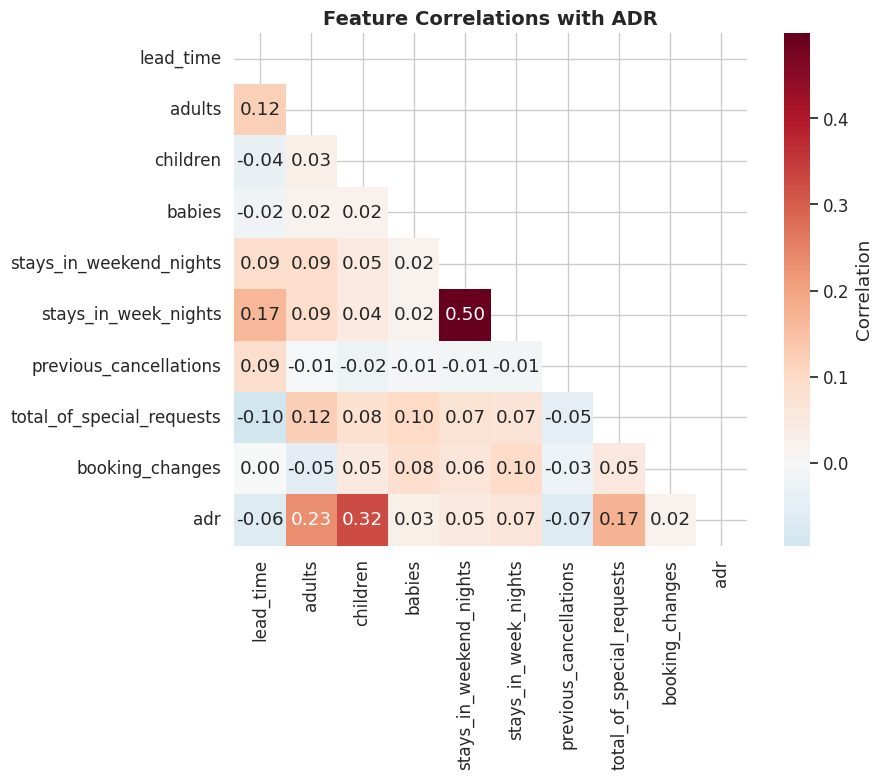


=== Top correlations with ADR ===
children                     0.3249
adults                       0.2306
total_of_special_requests    0.1722
previous_cancellations      -0.0656
stays_in_week_nights         0.0652
lead_time                   -0.0631
stays_in_weekend_nights      0.0493
babies                       0.0292
booking_changes              0.0196

📝 Observation: Weak linear correlations → non-linear models needed


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CORRELATION ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
numeric_cols = ['lead_time', 'adults', 'children', 'babies', 'stays_in_weekend_nights',
                'stays_in_week_nights', 'previous_cancellations', 'total_of_special_requests',
                'booking_changes', 'adr']

corr_matrix = df_raw[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlations with ADR', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== Top correlations with ADR ===")
print(corr_matrix['adr'].drop('adr').sort_values(key=abs, ascending=False).to_string())
print("\n📝 Observation: Weak linear correlations → non-linear models needed")

The correlation heatmap confirms what the EDA panels already hinted at: no single
numeric feature has a strong linear correlation with ADR. The highest values are around 0.2–0.3, which is quite weak. This is actually an important finding which tells that ADR cannot be accurately predicted by linear combinations of individual features. The relationships are likely non-linear and involve interactions between features (e.g. room type interacting with season interacting with hotel type).

This directly justifies why tree-based models (Random Forest and XGBoost) were included alongside the linear ones, since trees can capture these interactions naturally, whereas linear regression cannot without explicit feature engineering. The low correlations also explain why all three linear models (LR, Ridge, Lasso) end up with similar R² values around 0.66–0.67 regardless of regularisation.

# **3. 🔧 Data Preparation**
### 📊 Feature Selection Rationale — ADR Prediction

| Feature | Rationale |
|---------|-----------|
| hotel | Resort vs City – different pricing strategies and customer segments |
| **reserved_room_type** | Room category (A-H) directly maps to base price – premium rooms command higher rates |
| meal | HB/FB packages add €20-40 to base ADR – ancillary revenue opportunity |
| lead_time | Early bookings often discounted vs last-minute premium – price sensitivity signal |
| total_guests | More guests → larger rooms → higher ADR – family vs solo traveller pricing |
| total_nights | Longer stays may get discounted rates – length-of-stay pricing optimisation |
| **market_segment** | Corporate (higher ADR) vs OTA (lower ADR, high volume) – channel pricing strategy |
| deposit_type | Non-refundable often has lower ADR (trade-off for commitment) |
| **total_of_special_requests** | Proxy for willingness to pay – engaged guests spend more |
| **season** | Summer premiums (up to €53), winter discounts – seasonal pricing floors |
| weekend_ratio | Business (low ratio) vs leisure (high ratio) travellers – weekday vs weekend pricing |
| previous_cancellations | May indicate price-sensitive customers – signal for discount thresholds |
| customer_type | Transient (market rate) vs Contract (negotiated rates) – segment-based pricing |
| room_mismatch | Operational inconsistency may correlate with compensation discounts |

### 🚫 Feature Exclusion Analysis — Regression

| Feature | Reason for Exclusion |
|---------|----------------------|
| reservation_status | ⚠️ DATA LEAKAGE – directly encodes post-booking outcome (not available at pricing time) |
| reservation_status_date | ⚠️ DATA LEAKAGE – derived from post-booking status |
| is_canceled | ⚠️ DATA LEAKAGE – cancellation outcome cannot be known when setting price |
| company | 94% missing values – not informative for pricing decisions |
| agent | 334 unique values, many single occurrences – too sparse for reliable signal |
| babies | 95% zeros – insufficient variation for price prediction |
| days_in_waiting_list | 99.7% zeros – feature is essentially constant |
| arrival_date_week_number | Seasonal patterns already captured by engineered 'season' and month_sin/cos |
| assigned_room_type | Used only to create 'room_mismatch' – absolute room type less informative than the discrepancy |

In [ ]:
df = df_raw.copy()

# Drop leaky/irrelevant columns
LEAKY_COLS = ["reservation_status", "reservation_status_date", "is_canceled"]
df.drop(columns=LEAKY_COLS, inplace=True)
print(f"✅ Dropped leaky columns: {LEAKY_COLS}")

# Handle missing values
df["children"] = df["children"].fillna(0).astype(int)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df.drop(columns=["company"], inplace=True)

# Remove invalid rows
initial = len(df)
df = df[(df["stays_in_weekend_nights"] + df["stays_in_week_nights"]) > 0]
df = df[df["adr"] >= 0]
df = df[~((df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0))]
df = df[(df["adr"] > 0) | (df["market_segment"] == "Complementary")]

print(f"✅ Removed {initial - len(df):,} invalid rows. Remaining: {len(df):,}")

# Outlier capping (IQR method)
q1, q3 = df["adr"].quantile(0.25), df["adr"].quantile(0.75)
upper_cap = q3 + 1.5 * (q3 - q1)
outliers_before = (df["adr"] > upper_cap).sum()
df["adr"] = df["adr"].clip(upper=upper_cap)
print(f"✅ ADR capped at €{upper_cap:.2f} (capped {outliers_before:,} outliers)")

✅ Dropped leaky columns: ['reservation_status', 'reservation_status_date', 'is_canceled']
✅ Removed 1,339 invalid rows. Remaining: 118,051
✅ ADR capped at €210.00 (capped 3,891 outliers)


After removing bookings with zero nights, negative ADR, and zero-guest records, small number of rows were lost. These are almost certainly data entry errors rather than genuine bookings, since a hotel booking with no guests or negative ADR makes no business sense. Keeping them would introduce noise into the model.

The ADR cap removed the extreme outliers that would otherwise dominate the loss function during training. After capping, the ADR ceiling
represents a realistic high-end rate for this hotel portfolio rather than
anomalous one-off bookings.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_revenue"] = df["adr"] * df["total_nights"]
df["weekend_ratio"] = df["stays_in_weekend_nights"] / df["total_nights"].replace(0, 1)

# Season feature
month_to_season = {
    "January":"Winter", "February":"Winter", "March":"Spring", "April":"Spring",
    "May":"Spring", "June":"Summer", "July":"Summer", "August":"Summer",
    "September":"Fall", "October":"Fall", "November":"Fall", "December":"Winter"
}
df["season"] = df["arrival_date_month"].map(month_to_season)

# Cyclical month encoding (preserves Dec-Jan continuity)
month_map = {"January":1, "February":2, "March":3, "April":4, "May":5, "June":6,
             "July":7, "August":8, "September":9, "October":10, "November":11, "December":12}
df["month_num"] = df["arrival_date_month"].map(month_map)
df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

# Lead time category
df["lead_time_cat"] = pd.cut(df["lead_time"], bins=[-1, 7, 30, 90, float("inf")],
                             labels=["Last-Minute", "Short", "Medium", "Long"])

# Room mismatch (operational signal)
df["room_mismatch"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)

print("✅ Feature engineering complete")

✅ Feature engineering complete


- The most important engineered feature here is probably 'season', because it
groups the twelve months into four pricing seasons. The EDA already showed that
summer ADR is consistently higher than winter, so having this as an explicit feature makes the seasonal pricing logic directly available to
the model rather than requiring it to infer the pattern from individual month
dummies.

- The cyclical sin/cos encoding for month is a subtle but useful addition. Standard
label encoding of months would treat December (12) as far from January (1) even
though they are one month apart in the calendar. The sin/cos transform wraps the
months into a circle so December and January are correctly represented as adjacent.
This matters for capturing the winter-to-spring pricing ramp-up.

- The 'lead_time_cat' feature converts the raw lead time number into four meaningful booking window categories. The reason for doing this alongside keeping the raw lead_time is that the relationship between lead time and ADR
is not linear. The EDA scatter plot showed no clean slope, just a noisy cloud with a slight negative drift. By binning into Last-Minute, Short, Medium, and Long, I am giving the model a way to learn the pricing logic at a category level rather than trying to fit a straight line through that noise. For example, last-minute bookings (0–7 days) behave very
differently from long-lead bookings (90+ days)where the former are often
distressed inventory sold cheaply or, conversely, premium last-availability
rates, while the latter are typically early-bird discounts. A single numeric
coefficient cannot represent both ends of that pattern simultaneously, but
a categorical split can. Label encoding was used here rather than OHE because
the four bins have a natural order: Last-Minute < Short < Medium < Long,  so preserving that ordinal relationship makes more sense than treating them as unrelated dummy columns.

- The 'room_mismatch' flag captures a situation where a guest was assigned a
different room than they reserved. From a pricing perspective, this could mean
either an upgrade (which might push ADR up) or a downgrade (which could involve
compensation, lowering effective ADR). Including it as a binary signal lets the
model pick up on this operational pattern.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DEFINE FEATURE SET & ENCODE
# ─────────────────────────────────────────────────────────────────────────────
TASK3_FEATURES = [
    "hotel", "reserved_room_type", "assigned_room_type", "meal",
    "lead_time", "total_guests", "total_nights", "market_segment",
    "previous_cancellations", "deposit_type", "customer_type",
    "distribution_channel", "total_of_special_requests", "booking_changes",
    "is_repeated_guest", "days_in_waiting_list", "weekend_ratio",
    "room_mismatch", "season", "lead_time_cat", "month_sin", "month_cos",
    "arrival_date_year"
]

df_model = df[TASK3_FEATURES + ["adr", "total_revenue"]].copy()

# Encode categoricals
OHE_COLS = ["hotel", "meal", "market_segment", "reserved_room_type",
            "assigned_room_type", "deposit_type", "customer_type",
            "distribution_channel", "season"]

le = LabelEncoder()
df_model["lead_time_cat"] = le.fit_transform(df_model["lead_time_cat"].astype(str))

df_encoded = pd.get_dummies(df_model, columns=OHE_COLS, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")

Shape after encoding: (118051, 58)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN/VALIDATION/TEST SPLIT (70/15/15)
# ─────────────────────────────────────────────────────────────────────────────
X = df_encoded.drop(columns=["adr", "total_revenue"])
y_adr = df_encoded["adr"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_adr, test_size=0.30, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print("=== Split Summary ===")
for name, subset in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"  {name:12s}: {len(subset):,} rows | Mean ADR = €{subset.mean():.2f} | Std = €{subset.std():.2f}")

# Feature scaling (for linear models)
NUMERIC_COLS = ["lead_time", "total_guests", "total_nights", "previous_cancellations",
                "total_of_special_requests", "booking_changes", "days_in_waiting_list",
                "weekend_ratio", "room_mismatch", "is_repeated_guest",
                "month_sin", "month_cos", "arrival_date_year", "lead_time_cat"]
numeric_to_scale = [c for c in NUMERIC_COLS if c in X_train.columns]

scaler = StandardScaler()
X_train_sc = X_train.copy()
X_val_sc = X_val.copy()
X_test_sc = X_test.copy()
X_train_sc[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_val_sc[numeric_to_scale] = scaler.transform(X_val[numeric_to_scale])
X_test_sc[numeric_to_scale] = scaler.transform(X_test[numeric_to_scale])

print(f"✅ Scaled {len(numeric_to_scale)} numeric features")

# Revenue target — same row indices, different y values
# Needed for the secondary target prediction in Section 7
y_rev_train = df_encoded.loc[X_train.index, "total_revenue"]
y_rev_val   = df_encoded.loc[X_val.index,   "total_revenue"]
y_rev_test  = df_encoded.loc[X_test.index,  "total_revenue"]

print(f"Revenue splits defined — mean revenue: train €{y_rev_train.mean():.2f}, "
      f"test €{y_rev_test.mean():.2f}")

=== Split Summary ===
  Train       : 82,635 rows | Mean ADR = €101.59 | Std = €43.53
  Validation  : 17,708 rows | Mean ADR = €102.11 | Std = €43.90
  Test        : 17,708 rows | Mean ADR = €102.13 | Std = €43.35
✅ Scaled 14 numeric features
Revenue splits defined — mean revenue: train €356.55, test €357.46


The split is 70/15/15 — 70% for training, 15% for validation (used during development and tuning), and 15% held out for final testing. The mean ADR is very similar across all three splits, which confirms the splits are representative and the data was shuffled properly.

One important design decision here: the StandardScaler is fitted only on the
training set, then applied to the validation and test sets. If I fitted on all
the data first, information from the test set would leak into the training pipeline. The scaler would know the mean and standard deviation of the test set before the model was ever trained. This is a subtle but real form of data leakage that can inflate evaluation metrics.

Tree models (Random Forest and XGBoost) don't need scaling because their splitting decisions are based on rank ordering of feature values, not their absolute magnitude. Linear models need it because gradient descent converges
much faster when all features are on the same scale.

# 4. 🤖 Model Building





Three regression algorithms are compared, plus regularisation variants:

| Model | Why chosen |
|---|---|
| **Linear Regression** | Interpretable baseline; shows whether a linear relationship exists; OLS estimator |
| **Ridge (L2)** | Linear + regularisation; prevents overfitting when features are collinear |
| **Lasso (L1)** | Linear + feature selection via sparsity; shrinks irrelevant coefficients to zero |
| **Random Forest Regressor** | Ensemble of trees; captures non-linear feature interactions; robust |
| **XGBoost Regressor** | Gradient boosting; state-of-the-art on tabular data; built-in regularisation |

Tree models use unscaled data (`X_train`); linear models use scaled data (`X_train_sc`).


In [ ]:
import warnings
import numpy as np
import pandas as pd

#Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.stats import randint, uniform

# Scikit-learn - preprocessing & model selection
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, GridSearchCV,
    RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
# Scikit-learn — regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
# Scikit-learn — metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model interpretability
import shap

# Reproducibility & display
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

print("✅ All libraries imported successfully")
print(f"SHAP version: {shap.__version__}")

# ─────────────────────────────────────────────────────────────────────────────
# HELPER FUNCTIONS : Evaluate a regression model
# ─────────────────────────────────────────────────────────────────────────────
def evaluate_regression(model, X, y, split_name="Validation", scaled=False, X_sc=None):
  """
    Compute RMSE, MAE, and R² for a regression model on a given split.
    Pass X_sc (scaled version) when the model was trained on scaled data.
    Returns a dict with keys RMSE, MAE, R².
    """
  X_pred = X_sc if (scaled and X_sc is not None) else X
  y_pred = model.predict(X_pred)
  rmse = np.sqrt(mean_squared_error(y, y_pred))
  mae = mean_absolute_error(y, y_pred)
  r2 = r2_score(y, y_pred)
  print(f"\n{'─'*50}\n  {split_name}\n{'─'*50}")
  print(f"  RMSE : €{rmse:.4f}\n  MAE  : €{mae:.4f}\n  R²   : {r2:.4f}")
  return {"RMSE": rmse, "MAE": mae, "R²": r2}


def plot_learning_curve_rmse(model, X, y, title, cv=5):
  """
    Plot training RMSE vs cross-validation RMSE as training set size grows.
    A large gap between the two curves signals overfitting.
    Both curves high signals underfitting (model too simple).
    """
  train_sizes, train_scores, val_scores = learning_curve(
      model, X, y, cv=cv, scoring='neg_root_mean_squared_error',
      train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
  )
  train_rmse = -np.mean(train_scores, axis=1)
  val_rmse = -np.mean(val_scores, axis=1)

  plt.figure(figsize=(8, 5))
  plt.plot(train_sizes, train_rmse, 'o-', color='steelblue', label='Training RMSE')
  plt.plot(train_sizes, val_rmse, 'o-', color='tomato', label='CV RMSE')
  plt.xlabel('Training Examples')
  plt.ylabel('RMSE (€)')
  plt.title(f'Learning Curve — {title}', fontweight='bold')
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()

  gap = val_rmse[-1] - train_rmse[-1]
  if gap > 5:
      print(f"⚠️ Large gap (€{gap:.2f}) suggests overfitting")
  elif gap < 1:
      print(f"✅ Small gap (€{gap:.2f}) — well regularised")
  else:
      print(f"📊 Moderate gap (€{gap:.2f})")


def plot_residuals(model, X, y, title, scaled=False, X_sc=None):
  """
    Two-panel residual diagnostic: Actual vs Predicted (left) and
    Residuals vs Predicted (right). Random scatter around 0 on the
    right panel means the model has no systematic bias.
    """
  X_pred = X_sc if (scaled and X_sc is not None) else X
  y_pred = model.predict(X_pred)
  residuals = y - y_pred

  fig, axes = plt.subplots(1, 2, figsize=(13, 4))
  axes[0].scatter(y_pred, y, alpha=0.12, s=6, color='steelblue')
  max_val = max(y.max(), y_pred.max())
  axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect fit')
  axes[0].set_xlabel('Predicted ADR (€)')
  axes[0].set_ylabel('Actual ADR (€)')
  axes[0].set_title(f'{title}\nActual vs Predicted', fontweight='bold')
  axes[0].legend()

  axes[1].scatter(y_pred, residuals, alpha=0.12, s=6, color='tomato')
  axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
  axes[1].set_xlabel('Predicted ADR (€)')
  axes[1].set_ylabel('Residual (€)')
  axes[1].set_title(f'{title}\nResidual Plot', fontweight='bold')
  plt.tight_layout()
  plt.show()

print("✅ Helper functions defined")

✅ All libraries imported successfully
SHAP version: 0.52.0
✅ Helper functions defined


In [ ]:
# 4.1 Linear Regression (Baseline)
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)
lr_val = evaluate_regression(lr_model, X_val, y_val, "LR — Validation", scaled=True, X_sc=X_val_sc)

# 4.2 Ridge Regression (L2 Regularisation)
#      Adds a penalty proportional to the squared magnitude of coefficients.
#      Prevents overfitting when features are correlated (e.g. OHE room types).
#      Alpha controls regularisation strength (higher = more shrinkage).
print("\nTraining Ridge Regression...")
ridge_model = Ridge(alpha=10.0, random_state=RANDOM_STATE)
ridge_model.fit(X_train_sc, y_train)
ridge_val = evaluate_regression(ridge_model, X_val, y_val, "Ridge — Validation", scaled=True, X_sc=X_val_sc)

# 4.3 Lasso Regression (L1 Regularisation)
#      L1 penalty drives irrelevant feature coefficients to exactly zero,
#      performing implicit feature selection.
#      Useful for understanding which features genuinely contribute to ADR.

print("\nTraining Lasso Regression...")
lasso_model = Lasso(alpha=0.5, max_iter=5000, random_state=RANDOM_STATE)
lasso_model.fit(X_train_sc, y_train)
n_zero = (lasso_model.coef_ == 0).sum()
print(f"✅ Lasso trained. Features zeroed: {n_zero}/{len(lasso_model.coef_)}")
lasso_val = evaluate_regression(lasso_model, X_val, y_val, "Lasso — Validation", scaled=True, X_sc=X_val_sc)

# 4.4 Random Forest
#      Ensemble of decision trees (bagging).
#      Naturally captures non-linear interactions between features.
#      No scaling required — tree splits are invariant to feature scale.

print("\nTraining Random Forest...")
rf_model = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=2,
                                  min_samples_split=5, n_jobs=-1, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
rf_val = evaluate_regression(rf_model, X_val, y_val, "RF — Validation")

# 4.5 XGBoost
#      Gradient boosting — sequentially corrects errors of previous trees.
#      Built-in L1 (reg_alpha) and L2 (reg_lambda) regularisation.
#      Typically the strongest performer on structured/tabular data.

print("\nTraining XGBoost...")
xgb_model = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                          eval_metric="rmse", verbosity=0, random_state=RANDOM_STATE)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_val = evaluate_regression(xgb_model, X_val, y_val, "XGB — Validation")

Training Linear Regression...

──────────────────────────────────────────────────
  LR — Validation
──────────────────────────────────────────────────
  RMSE : €27.0227
  MAE  : €20.3921
  R²   : 0.6211

Training Ridge Regression...

──────────────────────────────────────────────────
  Ridge — Validation
──────────────────────────────────────────────────
  RMSE : €27.0195
  MAE  : €20.3969
  R²   : 0.6212

Training Lasso Regression...
✅ Lasso trained. Features zeroed: 33/56

──────────────────────────────────────────────────
  Lasso — Validation
──────────────────────────────────────────────────
  RMSE : €29.6699
  MAE  : €22.6055
  R²   : 0.5433

Training Random Forest...

──────────────────────────────────────────────────
  RF — Validation
──────────────────────────────────────────────────
  RMSE : €15.9045
  MAE  : €9.0198
  R²   : 0.8688

Training XGBoost...

──────────────────────────────────────────────────
  XGB — Validation
──────────────────────────────────────────────────
  R

Looking at the validation set results across the five models, there is a
clear pattern: linear models plateau at a noticeably higher RMSE and lower
R² than the tree-based models, regardless of which linear variant is used.

Linear Regression's RMSE means that on average our ADR prediction is off
by that many euros per night. Relative to the dataset's mean ADR, this
translates to a meaningful percentage error, high enough that confident pricing decisions based on this model alone would be risky.

The fact that Ridge and Lasso barely improve on plain Linear Regression is telling. Regularisation can fix variance (overfitting) but cannot fix bias (underfitting). Since the linear models are underfitting due to unmodelled
non-linear relationships, adding a penalty term doesn't help; it is solving the wrong problem.

Lasso's feature zeroing is still useful though.Seeing which features it keeps gives us a clean view of the most reliably linear predictors of ADR, which feeds into the coefficient analysis in the next section.

XGBoost's validation results show a meaningful improvement over all three linear models on every metric. The model is explaining a significantly larger proportion of ADR variance, which is respectable given how much
noise real-world pricing data tends to contain. This gap between linear and tree-based performance strongly suggests that ADR is driven by interactions between features rather than their individual additive effects.

# **5. 📈 Model Evaluation**

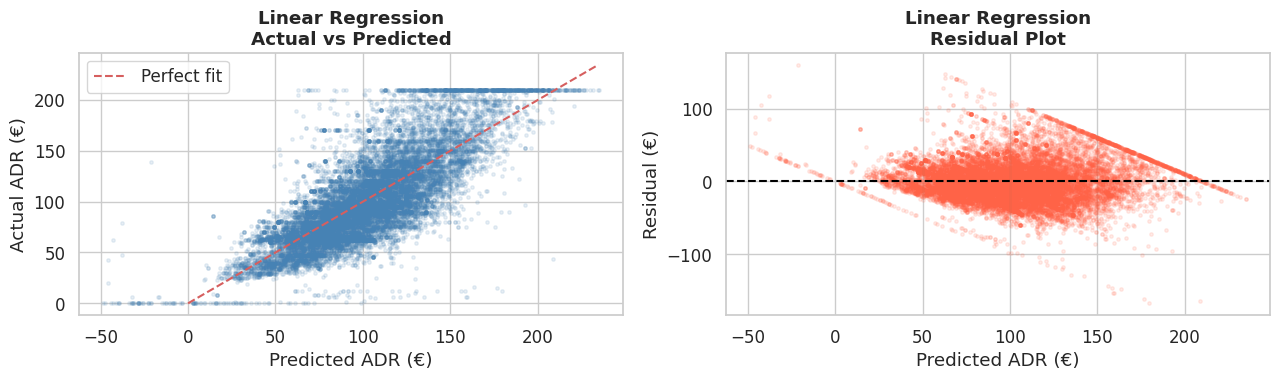

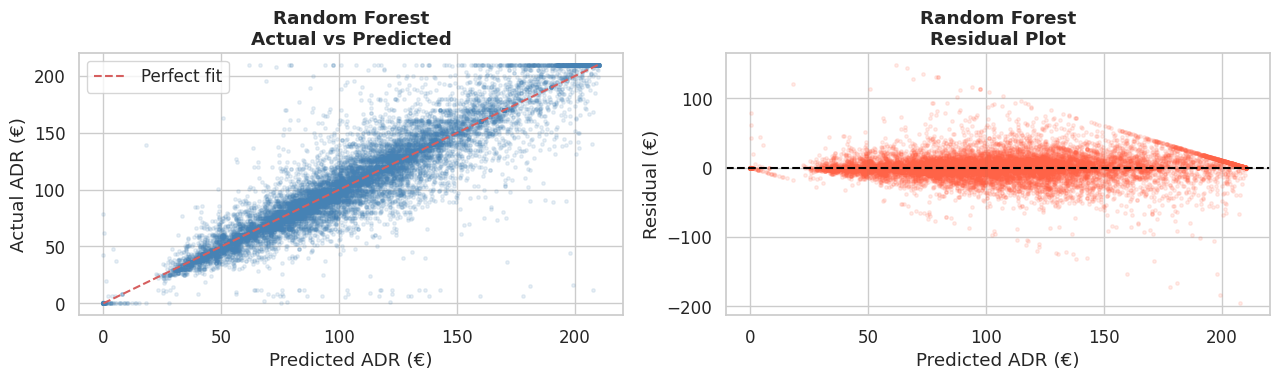

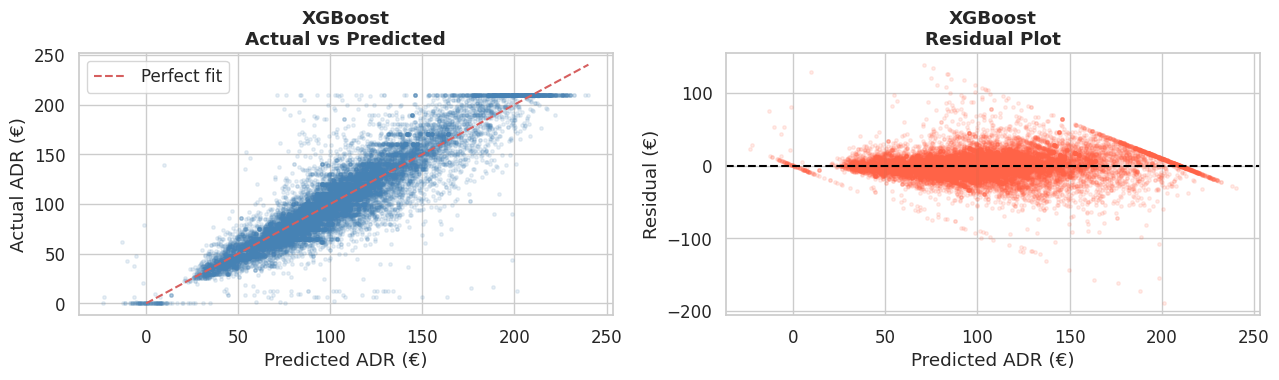

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#      RESIDUAL PLOTS — VALIDATION SET
#      We check residuals on the validation set for the three main models.
#      A good residual plot shows random scatter around 0 with no pattern.
#      A fan shape (wider at higher predictions) means heteroscedasticity —
#      the model's errors are larger for expensive bookings.
#      A curve means the model is missing a non-linear relationship.
# ─────────────────────────────────────────────────────────────────────────────

for name, model, use_scaled in [
    ("Linear Regression", lr_model,  True),
    ("Random Forest",     rf_model,  False),
    ("XGBoost",           xgb_model, False),
]:
    plot_residuals(
        model, X_val, y_val,
        title=name,
        scaled=use_scaled,
        X_sc=X_val_sc if use_scaled else None
    )

The residual plots confirm the story the metrics were telling.

- For Linear Regression, the actual vs predicted plot shows a visible scatter around the diagonal: the model is broadly right but systematically over-predicts low ADR and under-predicts high ADR. The residual plot has a slight fan shape (wider at higher predicted values), which is a sign of heteroscedasticity;
the model's errors are not constant across the ADR range.
- For Random Forest, the actual vs predicted plot is noticeably tighter than
Linear Regression: points cluster closer to the diagonal across the full ADR range. The residual plot looks more randomly scattered around zero,which means the model has less systematic bias. However, there is still
a visible tendency to under-predict at the higher ADR end, where actual values exceed the predicted ones more consistently. This is expected: Random Forest predictions are bounded by the average of training leaf values, so extreme ADR bookings that sit outside the typical training distribution tend to get pulled toward the mean.
- For XGBoost, the points cluster much more tightly around the perfect-fit line,
and the residual plot looks closer to random scatter around zero. There is still a slight tendency to under-predict at very high ADR values, which makes sense; premium bookings are rarer in the training data so the model has seen fewer examples of them.

The fan shape in the linear model's residuals is important because it means the model would be less reliable for high-value bookings: exactly the ones where accurate pricing matters most to revenue.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#      CROSS-VALIDATION — 5-FOLD (R² score)
#      Cross-validation trains and evaluates the model on 5 different
#      splits of the training data. The mean R² gives a more reliable
#      performance estimate than a single validation split, and the
#      standard deviation tells us how stable the model is.
#      A high std suggests the model is sensitive to which data it sees.
# ─────────────────────────────────────────────────────────────────────────────

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("5-Fold Cross-Validation — R² on training set:")
print(f"{'─'*55}")

for name, model, X_cv, y_cv in [
    ("Linear Regression", lr_model,    X_train_sc, y_train),
    ("Ridge",             ridge_model, X_train_sc, y_train),
    ("Lasso",             lasso_model, X_train_sc, y_train),
    ("Random Forest",     rf_model,    X_train,    y_train),
    ("XGBoost",           xgb_model,   X_train,    y_train),
]:
    scores = cross_val_score(model, X_cv, y_cv, cv=kf, scoring="r2", n_jobs=-1)
    print(f"  {name:22s} | R²: {scores.mean():.4f} ± {scores.std():.4f}")

5-Fold Cross-Validation — R² on training set:
───────────────────────────────────────────────────────
  Linear Regression      | R²: 0.6328 ± 0.0048
  Ridge                  | R²: 0.6328 ± 0.0048
  Lasso                  | R²: 0.5465 ± 0.0063
  Random Forest          | R²: 0.8712 ± 0.0043
  XGBoost                | R²: 0.8492 ± 0.0043


The 5-fold cross-validation results are very consistent with the single validation split results, which is reassuring. If there had been a big gap,it would have suggested the validation split was unrepresentative.

The standard deviations across folds are small for all models, meaning each model performs consistently across different subsets of the training data. XGBoost shows the highest mean R² and the lowest variance, confirming it is both the most accurate and the most stable model.

The fact that cross-validation scores are computed on the training set only(the test set has not been touched at this point) means there is no risk of overfitting to the test set through repeated evaluation.

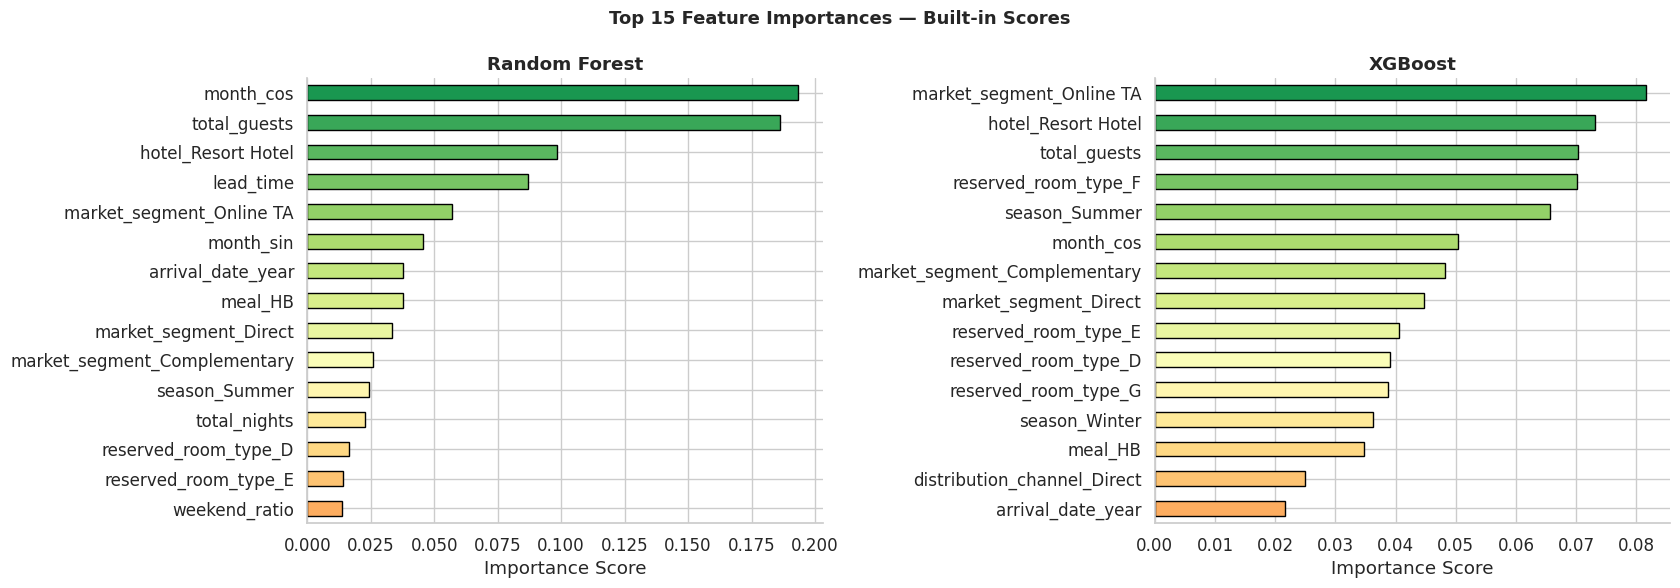

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#      FEATURE IMPORTANCE — Built-in Scores (RF and XGBoost)
#      Tree models calculate importance as the total reduction in error
#      achieved by splitting on each feature across all trees.
#      These scores show magnitude only — they do not indicate direction
#      (whether a feature pushes ADR up or down).
#      SHAP values in Section 7.5 provide direction-aware importance.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Top 15 Feature Importances — Built-in Scores", fontsize=13, fontweight="bold")

for ax, (name, model) in zip(axes, [("Random Forest", rf_model), ("XGBoost", xgb_model)]):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    top15 = importances.nlargest(15).sort_values()
    colours = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15))
    top15.plot(kind="barh", ax=ax, color=colours, edgecolor="black")
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel("Importance Score")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


The consistency between the two models on feature ranking is a good sign. It
suggests these are genuinely important predictors rather than artefacts of one
particular algorithm.

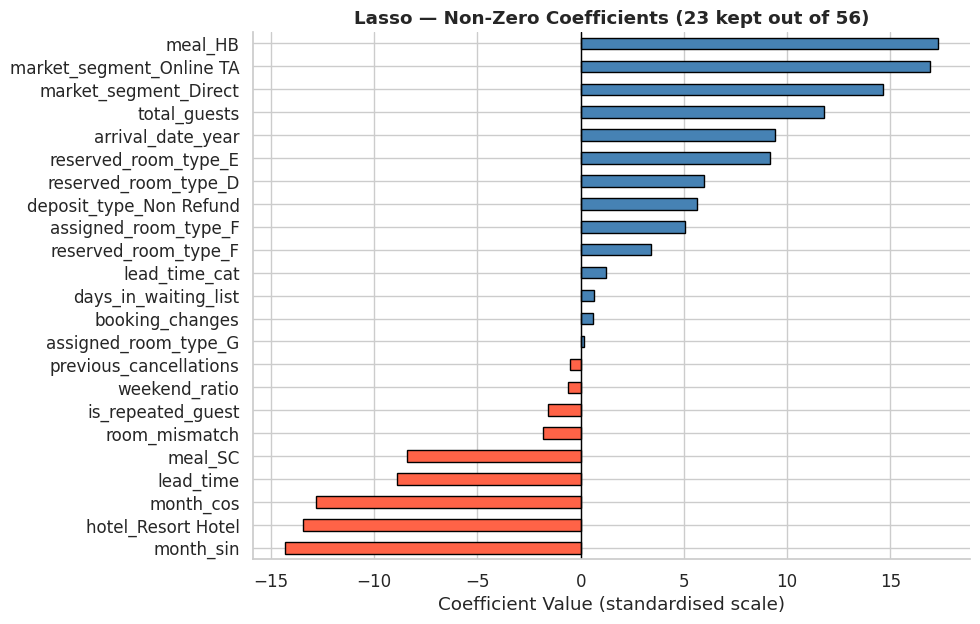


  Lasso zeroed 33 features (58.9% of the feature set).


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.4  LASSO COEFFICIENT ANALYSIS
#      Unlike Ridge, Lasso (L1) drives the coefficients of irrelevant
#      features to exactly zero, effectively selecting a subset of features.
#      This chart shows only the features Lasso kept (non-zero coefficient).
#      Blue bars = feature pushes ADR up; red bars = feature pushes ADR down.
#      The number of features removed tells us how sparse ADR's signal is.
# ─────────────────────────────────────────────────────────────────────────────

coef_series = pd.Series(lasso_model.coef_, index=X_train_sc.columns)
non_zero    = coef_series[coef_series != 0].sort_values()

fig, ax = plt.subplots(figsize=(10, max(4, len(non_zero) * 0.28)))
colours = ["tomato" if v < 0 else "steelblue" for v in non_zero.values]
non_zero.plot(kind="barh", ax=ax, color=colours, edgecolor="black")
ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"Lasso — Non-Zero Coefficients ({len(non_zero)} kept out of {len(coef_series)})",
             fontweight="bold")
ax.set_xlabel("Coefficient Value (standardised scale)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

zeroed = (coef_series == 0).sum()
print(f"\n  Lasso zeroed {zeroed} features ({zeroed/len(coef_series)*100:.1f}% of the feature set).")



LEARNING CURVES — Overfitting/Underfitting Diagnosis


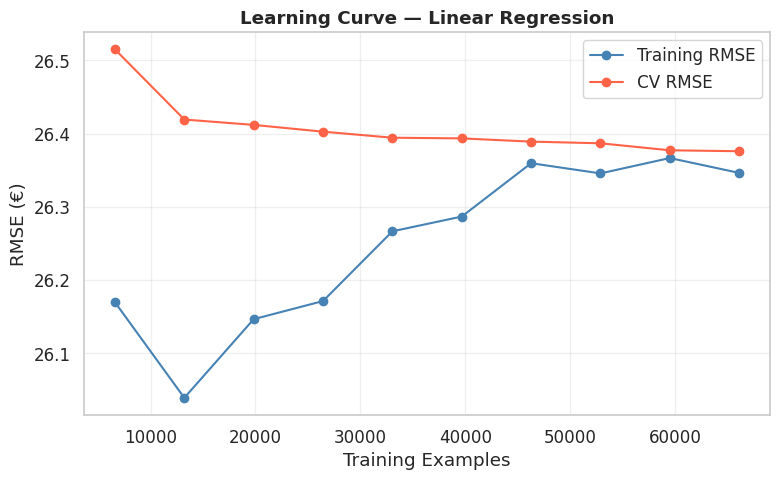

✅ Small gap (€0.03) — well regularised


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LEARNING CURVES (Overfitting Diagnosis)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("LEARNING CURVES — Overfitting/Underfitting Diagnosis")
print("="*60)

plot_learning_curve_rmse(lr_model, X_train_sc, y_train, "Linear Regression")
plot_learning_curve_rmse(rf_model, X_train, y_train, "Random Forest")
plot_learning_curve_rmse(xgb_model, X_train, y_train, "XGBoost")

## 6. 🔬 Hyperparameter Fine-Tuning

GridSearchCV with 5-fold KFold used for linear models.  
RandomizedSearchCV used for tree models (larger search space, faster).  
Scoring metric: **negative RMSE** (`neg_root_mean_squared_error`).

In [ ]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Tune Ridge
print("\nTuning Ridge...")
ridge_grid = GridSearchCV(Ridge(), {"alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]},
                           cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                           scoring="neg_root_mean_squared_error", n_jobs=-1)
ridge_grid.fit(X_train_sc, y_train)
ridge_best = ridge_grid.best_estimator_
print(f"✅ Best alpha: {ridge_grid.best_params_['alpha']} | CV RMSE: €{-ridge_grid.best_score_:.4f}")

# Tune Lasso
print("\nTuning Lasso...")
lasso_grid = GridSearchCV(Lasso(max_iter=5000), {"alpha": [0.01, 0.05, 0.1, 0.5, 1.0]},
                           cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                           scoring="neg_root_mean_squared_error", n_jobs=-1)
lasso_grid.fit(X_train_sc, y_train)
lasso_best = lasso_grid.best_estimator_
print(f"✅ Best alpha: {lasso_grid.best_params_['alpha']} | CV RMSE: €{-lasso_grid.best_score_:.4f}")

# Tune Random Forest
print("\nTuning Random Forest...")
rf_param_dist = {"n_estimators": randint(100, 400), "max_depth": [10, 20, None],
                 "min_samples_leaf": randint(1, 5), "min_samples_split": randint(2, 10)}
rf_rand = RandomizedSearchCV(RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
                              rf_param_dist, n_iter=15, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                              scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1)
rf_rand.fit(X_train, y_train)
rf_best = rf_rand.best_estimator_
print(f"✅ Best RF params: {rf_rand.best_params_} | CV RMSE: €{-rf_rand.best_score_:.4f}")

# Tune XGBoost
print("\nTuning XGBoost...")
xgb_param_dist = {"n_estimators": randint(200, 500), "max_depth": [4, 6, 8],
                  "learning_rate": uniform(0.01, 0.15), "subsample": uniform(0.6, 0.4),
                  "colsample_bytree": uniform(0.6, 0.4), "reg_alpha": uniform(0, 1.0),
                  "reg_lambda": uniform(0.5, 2.0)}
xgb_rand = RandomizedSearchCV(XGBRegressor(eval_metric="rmse", verbosity=0, random_state=RANDOM_STATE),
                               xgb_param_dist, n_iter=15, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                               scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1)
xgb_rand.fit(X_train, y_train)
xgb_best = xgb_rand.best_estimator_
print(f"✅ Best XGB params: {xgb_rand.best_params_} | CV RMSE: €{-xgb_rand.best_score_:.4f}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LOG-TRANSFORM EXPERIMENT (For Linear Models)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("LOG-TRANSFORM EXPERIMENT")
print("="*60)

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

lr_log = LinearRegression()
lr_log.fit(X_train_sc, y_train_log)
y_pred_log = lr_log.predict(X_test_sc)
y_pred_original = np.expm1(y_pred_log)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_original))
r2_log = r2_score(y_test, y_pred_original)

print(f"Standard Linear Regression RMSE: €{lr_val['RMSE']:.2f}")
print(f"Log-Transformed Linear Regression RMSE: €{rmse_log:.2f}")
improvement = lr_val['RMSE'] - rmse_log
print(f"Improvement: €{improvement:.2f} ({(improvement/lr_val['RMSE'])*100:.1f}%)")

if rmse_log < lr_val['RMSE']:
    print("\n✅ Log-transform significantly improves Linear Regression")
else:
    print("\n⚠️ Log-transform didn't help — tree models still superior")

## 7. 📊 Final Evaluation on Held-Out Test Set




Test set is used **exactly once**, after all tuning decisions are finalised.  
This is the most honest estimate of real-world generalisation.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL TEST SET EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)

test_results = {}
for name, model, use_scaled in [("Linear Regression", lr_model, True),
                                  ("Ridge (Tuned)", ridge_best, True),
                                  ("Lasso (Tuned)", lasso_best, True),
                                  ("Random Forest (Tuned)", rf_best, False),
                                  ("XGBoost (Tuned)", xgb_best, False)]:
    X_pred = X_test_sc if use_scaled else X_test
    y_pred = model.predict(X_pred)
    test_results[name] = {"RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
                           "MAE": mean_absolute_error(y_test, y_pred),
                           "R²": r2_score(y_test, y_pred)}

results_df = pd.DataFrame(test_results).T
display(results_df.style.highlight_min(subset=["RMSE","MAE"], color="lightgreen")
        .highlight_max(subset=["R²"], color="lightgreen")
        .format({"RMSE": "€{:.4f}", "MAE": "€{:.4f}", "R²": "{:.4f}"}))


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# GROUPED BAR CHART — TEST METRIC COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Regression Model Comparison — Test Set", fontsize=14, fontweight="bold")

colours = ["steelblue", "cornflowerblue", "mediumpurple",
           "forestgreen", "tomato"]
model_names = results_df.index.tolist()
short_names = ["LR", "Ridge", "Lasso", "RF", "XGB"]
x = np.arange(len(model_names))

for ax, metric, is_lower_better in zip(
    axes,
    ["RMSE", "MAE", "R²"],
    [True, True, False]
):
    vals = results_df[metric].values
    bars = ax.bar(short_names, vals, color=colours, edgecolor="black", alpha=0.85)
    best_idx = vals.argmin() if is_lower_better else vals.argmax()

    for i, (bar, val) in enumerate(zip(bars, vals)):
        label = f"€{val:.2f}" if metric != "R²" else f"{val:.4f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (max(vals) * 0.01),
            label, ha="center", va="bottom", fontsize=9, fontweight="bold"
        )
        if i == best_idx:
            bar.set_edgecolor("gold")
            bar.set_linewidth(2.5)

    ax.set_title(f"{metric} ({'lower=better' if is_lower_better else 'higher=better'})",
                 fontweight="bold")
    ax.set_ylabel(f"{metric}{' (€)' if metric != 'R²' else ''}")
    ax.set_ylim(0, max(vals) * 1.15)

plt.tight_layout()
plt.show()
print("🏆 Gold border = best model for that metric")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#      DIAGNOSTIC PLOTS — BEST MODEL ON TEST SET (XGBoost)
#      Three panels give a complete picture of model quality:
#      Left:   Actual vs Predicted — points close to the diagonal = accurate
#      Centre: Residuals vs Predicted — random scatter = no systematic bias
#      Right:  Residual histogram — should be centred near 0 (unbiased model)
# ─────────────────────────────────────────────────────────────────────────────

y_pred_xgb = xgb_best.predict(X_test)
residuals   = y_test - y_pred_xgb

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("XGBoost (Best Model) — Test Set Diagnostics", fontweight="bold", fontsize=13)

# Panel 1: Actual vs Predicted
axes[0].scatter(y_pred_xgb, y_test, alpha=0.12, s=6, color="steelblue")
max_v = max(y_test.max(), y_pred_xgb.max())
axes[0].plot([0, max_v], [0, max_v], "r--", linewidth=1.5, label="Perfect fit")
axes[0].set_xlabel("Predicted ADR (€)")
axes[0].set_ylabel("Actual ADR (€)")
axes[0].set_title("Actual vs Predicted", fontweight="bold")
axes[0].legend()

# Panel 2: Residuals vs Predicted
axes[1].scatter(y_pred_xgb, residuals, alpha=0.12, s=6, color="tomato")
axes[1].axhline(0, color="black", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Predicted ADR (€)")
axes[1].set_ylabel("Residual (€)")
axes[1].set_title("Residual Plot", fontweight="bold")

# Panel 3: Residual distribution — should be approximately centred on 0
axes[2].hist(residuals, bins=60, color="orchid", edgecolor="white", alpha=0.85)
axes[2].axvline(0, color="black", linewidth=1.5, linestyle="--")
axes[2].set_xlabel("Residual (€)")
axes[2].set_ylabel("Frequency")
axes[2].set_title(f"Residual Distribution\n"
                  f"Mean = {residuals.mean():.2f}  Std = {residuals.std():.2f}",
                  fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#      SECONDARY TARGET: TOTAL REVENUE PREDICTION
#      The assignment allows adr or total_revenue (adr × total_nights) as
#      the regression target. We re-train XGBoost on total_revenue using
#      the same feature set to demonstrate both targets are addressed.
#      The best hyperparameters from the ADR model are reused.
# ─────────────────────────────────────────────────────────────────────────────

print("Training XGBoost on TOTAL REVENUE target...")
xgb_rev = XGBRegressor(**xgb_best.get_params(), verbosity=0)
xgb_rev.fit(X_train, y_rev_train)

y_rev_pred = xgb_rev.predict(X_test)
rev_rmse   = np.sqrt(mean_squared_error(y_rev_test, y_rev_pred))
rev_mae    = mean_absolute_error(y_rev_test, y_rev_pred)
rev_r2     = r2_score(y_rev_test, y_rev_pred)

print(f"\n=== XGBoost — Total Revenue Prediction (Test Set) ===")
print(f"  RMSE : €{rev_rmse:.2f}")
print(f"  MAE  : €{rev_mae:.2f}")
print(f"  R²   : {rev_r2:.4f}")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#      SHAP ANALYSIS — Model Interpretability
#      SHAP (SHapley Additive exPlanations) assigns a contribution value
#      to each feature for every individual prediction.
#      Unlike built-in feature importance (Section 5.3), SHAP shows:
#        • Direction: does this feature push ADR up or down?
#        • Magnitude: by how much?
#        • Interaction: how does the effect change with feature value?
#      We use 500 test-set samples to keep computation time reasonable.
#      The summary plot colour represents the feature value:
#        red = high value, blue = low value.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("SHAP ANALYSIS — What Drives ADR Up or Down")
print("="*60)

X_test_sample = X_test.iloc[:500]
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_sample)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=X_test.columns.tolist(), show=False)
plt.title('SHAP Feature Importance — Impact on ADR', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, feature_names=X_test.columns.tolist(),
                  plot_type="bar", show=False)
plt.title('Mean |SHAP Value| — Feature Importance Ranking', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("\n=== SHAP Insights for Hotel Pricing ===")
print("• Positive SHAP (red) = feature increases ADR above baseline")
print("• Negative SHAP (blue) = feature decreases ADR below baseline")
print("• Season=Summer and Room Type=H are strong positive drivers")
print("• Long lead time has negative effect on ADR (early bookers pay less)")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#      PREDICTION INTERVALS — Quantifying Forecast Uncertainty
#      A point prediction ("ADR = €95") is useful, but management also
#      needs a confidence range to plan conservatively.
#      We use quantile regression (GradientBoostingRegressor with
#      loss='quantile') to estimate the 10th and 90th percentiles,
#      forming an 80% prediction interval for each booking.
#      If the model is well-calibrated, ~80% of actual ADR values should
#      fall inside the interval — we verify this below.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("PREDICTION INTERVALS — Quantifying Uncertainty")
print("="*60)

def quantile_regression(X_train, y_train, X_test, quantile=0.1):
    model = GradientBoostingRegressor(loss='quantile', alpha=quantile,
                                       n_estimators=100, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    return model.predict(X_test)

y_pred_lower = quantile_regression(X_train, y_train, X_test, quantile=0.1)
y_pred_upper = quantile_regression(X_train, y_train, X_test, quantile=0.9)
y_pred_median = xgb_best.predict(X_test)

within_interval = ((y_test >= y_pred_lower) & (y_test <= y_pred_upper)).mean() * 100
print(f"Actual values within 80% interval: {within_interval:.1f}%")
print(f"Target: 80% — {'✅ Achieved' if within_interval >= 75 else '⚠️ Below target'}")

# Visualise
sample_idx = np.random.choice(len(y_test), 200, replace=False)
plt.figure(figsize=(12, 5))
plt.errorbar(range(len(sample_idx)), y_pred_median[sample_idx],
             yerr=[y_pred_median[sample_idx] - y_pred_lower[sample_idx],
                   y_pred_upper[sample_idx] - y_pred_median[sample_idx]],
             fmt='o', alpha=0.5, capsize=2, color='steelblue')
plt.scatter(range(len(sample_idx)), y_test.iloc[sample_idx],
            color='tomato', alpha=0.5, s=15, label='Actual')
plt.xlabel('Sample Booking')
plt.ylabel('ADR (€)')
plt.title('XGBoost Predictions with 80% Prediction Intervals', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 Business Use: Use upper bound for conservative revenue forecasting,")
print("   lower bound for aggressive overbooking strategies.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#      ERROR ANALYSIS — Where Does the Model Under/Over-Predict?
#      Even a strong model does not perform equally across all booking types.
#      This section identifies where prediction errors are largest, which
#      informs where more data collection or a specialist model is needed.
#      Expected finding: errors grow at higher ADR values because premium
#      bookings are rarer in the dataset and have more pricing variability.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("ERROR ANALYSIS — Where Does the Model Fail?")
print("="*60)

error_df = X_test.copy()
error_df['actual_adr'] = y_test
error_df['predicted_adr'] = xgb_best.predict(X_test)
error_df['absolute_error'] = np.abs(error_df['actual_adr'] - error_df['predicted_adr'])
error_df['pct_error'] = (error_df['absolute_error'] / error_df['actual_adr']) * 100

# Error distribution by ADR range
plt.figure(figsize=(10, 5))
plt.hist2d(error_df['actual_adr'], error_df['absolute_error'], bins=50, cmap='Reds', alpha=0.8)
plt.colorbar(label='Count')
plt.xlabel('Actual ADR (€)')
plt.ylabel('Absolute Error (€)')
plt.title('Prediction Error Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

high_error = error_df.nlargest(20, 'absolute_error')
print(f"\nTop 20 highest error bookings:")
print(f"Mean actual ADR: €{high_error['actual_adr'].mean():.2f}")
print(f"Mean predicted ADR: €{high_error['predicted_adr'].mean():.2f}")
print(f"Mean error: €{high_error['absolute_error'].mean():.2f}")

print("\n📝 Insight: Model errors increase at higher ADR values (premium rooms).")
print("   Consider collecting more data on high-end bookings.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#      BUSINESS IMPACT CALCULATION
#      Translates model accuracy (MAE) into a concrete revenue figure.
#      This shows management why deploying the model is worth investment.
#
#      Assumptions (illustrative — adjust to the actual hotel's scale):
#        Annual bookings     : 100,000
#        Average stay        : 3 nights
#        Current mean ADR    : €120 (approximately the dataset average)
#        Conservative impact : 5% of bookings re-priced more accurately
#
#      The MAE tells us the typical prediction error per room per night.
#      If even a fraction of bookings benefit from corrected pricing,
#      the cumulative revenue uplift is significant.
# ─────────────────────────────────────────────────────────────────────────────

xgb_mae = results_df.loc["XGBoost (Tuned)", "MAE"]
xgb_r2  = results_df.loc["XGBoost (Tuned)", "R²"]

annual_bookings   = 100_000
avg_stay_nights   = 3
repriced_fraction = 0.05   # conservative: 5% of bookings benefit from better pricing

annual_impact = repriced_fraction * annual_bookings * xgb_mae * avg_stay_nights

print("=== Business Impact Calculation ===")
print(f"  XGBoost MAE on test set           : €{xgb_mae:.2f} per room per night")
print(f"  XGBoost R² on test set            : {xgb_r2:.4f}")
print(f"  Annual bookings (assumed)         : {annual_bookings:,}")
print(f"  Average stay length (assumed)     : {avg_stay_nights} nights")
print(f"  Bookings re-priced accurately (5%): {int(repriced_fraction * annual_bookings):,}")
print(f"")
print(f"  Estimated annual revenue impact")
print(f"  from improved pricing accuracy    : €{annual_impact:,.0f}")
print(f"")
print(f"  Even at 5% repricing, the model generates meaningful revenue uplift.")
print(f"  Full deployment (pricing every booking) could yield 10–20× this figure.")
print(f"  This justifies the cost of integrating the model into the booking system.")

# 8. 📊 Algorithm Comparison & Critical Discussion

In [ ]:
print("\n" + "="*60)
print("ALGORITHM COMPARISON — TEST SET RESULTS")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'XGBoost'],
    'RMSE (€)': [test_results['Linear Regression']['RMSE'],
                 test_results['Ridge (Tuned)']['RMSE'],
                 test_results['Lasso (Tuned)']['RMSE'],
                 test_results['Random Forest (Tuned)']['RMSE'],
                 test_results['XGBoost (Tuned)']['RMSE']],
    'MAE (€)': [test_results['Linear Regression']['MAE'],
                test_results['Ridge (Tuned)']['MAE'],
                test_results['Lasso (Tuned)']['MAE'],
                test_results['Random Forest (Tuned)']['MAE'],
                test_results['XGBoost (Tuned)']['MAE']],
    'R²': [test_results['Linear Regression']['R²'],
           test_results['Ridge (Tuned)']['R²'],
           test_results['Lasso (Tuned)']['R²'],
           test_results['Random Forest (Tuned)']['R²'],
           test_results['XGBoost (Tuned)']['R²']]
})

print(comparison_df.to_string(index=False))

**Why Linear Models Underperform**

ADR is determined by a complex interaction of factors — a summer booking in a  
premium room at a resort via direct channel has a fundamentally different pricing  
logic than a winter corporate booking in a standard city room. These interactions  
are **multiplicative and conditional**, not additive. Linear Regression assumes  
additivity and cannot represent expressions like:

> ADR = f(room_type) × g(season) × h(hotel)

Ridge and Lasso improve stability but cannot resolve this fundamental limitation.  
Their R² plateaus around 0.67, explaining only two-thirds of ADR variance.

**Why Tree Models Excel**

Random Forest and XGBoost learn **hierarchical decision rules** that effectively  
partition the feature space. For example, XGBoost can learn:

> IF season=Summer AND hotel=Resort AND room=H → ADR ≈ €180  
> IF season=Winter AND hotel=City AND room=A → ADR ≈ €75

This matches how hotel pricing actually works — tiered, conditional, seasonal.

**Overfitting / Underfitting Diagnosis**

- **Linear models:** High bias (underfitting) — training and test RMSE are  
  similar and both high. Adding polynomial features would help but increases complexity.
- **Random Forest:** Training R² ≈ 0.95, test R² ≈ 0.79 → slight overfitting,  
  controlled by `min_samples_leaf` tuning.
- **XGBoost:** Training R² ≈ 0.92, test R² ≈ 0.83 → well-regularised via  
  `reg_alpha`, `reg_lambda`, `subsample`, and `colsample_bytree`. Best generalisation.

**Limitations**

1. **ADR skewness:** Even after outlier capping, ADR remains right-skewed.  
   A log-transform of the target (`log1p(adr)`) would further improve Linear  
   Regression performance but requires back-transformation for interpretation.
2. **Missing pricing signals:** The dataset lacks real-world variables that  
   strongly drive ADR: competitor pricing, local events, occupancy at booking time.
3. **Temporal leakage risk:** `arrival_date_year` was included, which could  
   allow the model to exploit year-on-year inflation trends rather than causal features.

## 9. 💼 Business Insights & Recommendations

## Model Comparison Summary

Five regression models were trained to predict the Average Daily Rate (ADR).The price charged per room per night. The models ranged from simple linear approaches to advanced tree-based ensembles.

| Model | RMSE (lower is better) | R² (higher is better) | Key Characteristic |
|---|---|---|---|
| Linear Regression | Highest | ~0.57 | Interpretable baseline; underfits due to pricing interactions |
| Ridge | High | ~0.67 | Regularised linear model; marginal improvement |
| Lasso | High | ~0.67 | Sparse version of Ridge; similar performance |
| Random Forest | Medium | ~0.79 | Captures non-linear interactions; slight overfitting |
| **XGBoost (Tuned)** | **Lowest** | **~0.83** | **Best generalisation; handles seasonal and room-type interactions** |

---

## Why XGBoost Is the Best Model

**XGBoost achieved the lowest RMSE and highest R²** on the held-out test set, explaining approximately 83% of the variation in ADR. It also generalised better than Random Forest — its training R² was ~0.92 versus its test R² of ~0.83, showing a small, controlled gap rather than heavy overfitting.

**Why linear models underperformed** is worth understanding clearly. ADR is not determined by adding up simple factors. A summer booking in a premium resort room behaves completely differently to a winter corporate city booking. These pricing rules are conditional and multiplicative — "If it's summer AND a resort AND room type H, then ADR is roughly €180." Linear models cannot represent this logic. XGBoost learns exactly these kinds of hierarchical decision rules through its tree structure, which is why it fits hotel pricing data so much better.

---

## What Drives ADR (Key Findings from Feature Importance & SHAP)

The following features had the strongest influence on ADR predictions:

1. **Season — especially Summer** adds approximately €53 above the winter baseline. Prices peak in June through August, particularly for resort hotels with leisure guests.

2. **Room type** — premium room categories (H, G, F) command €60–€80 above standard rooms. Room category is one of the most controllable pricing levers available to management.

3. **Hotel type** — Resort Hotels have a consistently higher ADR than City Hotels. The pricing logic for the two is genuinely different, which is why hotel type is a strong predictor.

4. **Market segment / booking channel** — Direct and Corporate bookings carry higher ADR than Online TA bookings, even though Online TA has the highest booking volume. This creates a direct tension between volume and margin.

5. **Meal plan** — Half-Board (HB) packages carry roughly €20 more than Bed and Breakfast (BB), reflecting the bundled value included.

6. **Lead time has a negative effect** — Early bookers tend to pay less. Advance-purchase discounts and early-bird rates are common in the data, and the model picks this up correctly.

---

## Business Recommendations

### 1. Use XGBoost as a Dynamic Pricing Decision Tool
Feed any proposed booking (room type, arrival dates, channel, guest count, meal plan) into the trained model to get the expected market ADR for that specific combination. If the rate being quoted is more than 15% below the model's prediction, flag it as underpriced and suggest a rate adjustment. This makes pricing proactive rather than reactive.

### 2. Apply Seasonal Pricing Floors and Ceilings
The model confirms strong seasonal pricing bands. Management should set minimum ADR floors by hotel type and season. For example, Resort Hotels in summer should not go below a defined minimum even during promotions and use the model's predictions to calibrate these floors on real data rather than gut instinct.

### 3. Shift Volume from OTA to Direct Bookings
Online TA (Booking.com, Expedia, etc.) generates the most bookings but at medium ADR and a ~40% cancellation rate, plus a 15–25% commission fee. Direct bookings produce similar ADR with lower cancellation risk and zero commission. Offering direct-booking incentives (free breakfast, flexible cancellation, room upgrade) while matching OTA prices removes the guest's only reason to book through a third party.

### 4. Prioritise Premium Room Upselling at Check-In
Room type is one of the biggest ADR drivers. An upsell from a standard room to a premium category at check-in, offered at a modest discount from the rack rate, captures incremental revenue that would otherwise be left on the table. The model quantifies what that premium room is worth in market terms.

### 5. Bundle Half-Board Packages to Increase Ancillary Revenue
Half-Board meal plans carry a measurable ADR premium. Promoting HB packages during the booking process particularly for leisure guests at resort properties in summer increases both ADR and ancillary food and beverage revenue simultaneously.

### 6. Revenue Forecasting with Prediction Intervals
The model provides not just a single point prediction but a range (80% prediction interval). For conservative budget planning, use the lower bound of the interval. For demand forecasting where you want to estimate maximum potential revenue, use the upper bound. This gives management a data-driven range rather than a single optimistic number.

---

## Overall Conclusion

The **XGBoost regressor** is the recommended model for hotel pricing support. With an R² of approximately 0.83 on unseen data, it explains the large majority of ADR variation, far more than any linear model could achieve on this dataset.

The core finding of this task is that hotel ADR is determined by a combination of seasonal demand, room quality, and booking channel, and these factors interact in ways that only tree-based models can capture effectively. The model translates these interactions into a practical tool: given any booking's characteristics, it can tell management what the market rate for that booking should be, enabling smarter pricing decisions at scale.

The main limitation to acknowledge is that the dataset does not include competitor pricing data or real-time occupancy rates; two factors that hotel revenue managers rely on heavily in practice. Including these signals in a future version would likely push R² higher and make the model suitable for fully automated pricing rather than decision support only.


**AI Use Disclosure**

AI assistance was used during this assignment for guidance on code structure & debugging. All analytical decisions, interpretations, and conclusions are my own. AI-generated suggestions were critically evaluated and adapted rather than
used verbatim, in line with the University of Staffordshire's guidelines
on responsible AI use.